# Outliers

## Dataset Used: solid_waste_generation_recycling

In [2]:
import pandas as pd

data = pd.read_csv(r"C:\Users\HP\A  Self Pace ML\18. Outliers\solid_waste_generation_recycling.csv")

In [3]:
data.head()

,Year,Agricultural Organic Waste,Aluminum Cans,Anti-freeze,Appliances/White Goods,"Ash, Sand & Dust used",Asphalt/Concrete,Batteries,Cardboard,Glass,...,Other_Waste_Type_49,Other_Waste_Type_50,Other_Waste_Type_51,Other_Waste_Type_52,Other_Waste_Type_53,Other_Waste_Type_54,Other_Waste_Type_55,Other_Waste_Type_56,Other_Waste_Type_57,Other_Waste_Type_58
0,2000,0,17944,2475,35427,10000,893218,25795,133104,11267,...,28249,149097,1639,3797,1332,23490,966,10951,26002,24295
1,2001,0,12540,4157,39180,12333,1116871,10860,103707,27912,...,21104,121315,827,1792,201,27589,4944,12079,23087,20682
2,2002,0,12718,4506,43833,290,1451959,15390,135305,21394,...,23429,127834,2730,2861,3507,22951,3432,12717,14873,26380
3,2003,0,17608,4722,53353,10576,1600288,21964,78693,13556,...,16371,64153,3531,3476,4212,22312,688,19692,11481,18519
4,2004,0,16010,8050,56920,40409,2002171,21284,121932,13890,...,16359,126325,4451,3417,574,11990,4243,17311,20093,29694


In [4]:
data.shape

(15, 80)

In [5]:
data.columns

Index(['Year', 'Agricultural Organic Waste', 'Aluminum Cans', 'Anti-freeze',
       'Appliances/White Goods', 'Ash, Sand & Dust used', 'Asphalt/Concrete',
       'Batteries', 'Cardboard', 'Glass', 'Paper', 'Plastics', 'Textiles',
       'Wood', 'Rubber', 'Leather', 'Yard Trimmings', 'Food Waste',
       'Electronics', 'Metals', 'Demolition Debris', 'Hazardous Waste',
       'Other_Waste_Type_1', 'Other_Waste_Type_2', 'Other_Waste_Type_3',
       'Other_Waste_Type_4', 'Other_Waste_Type_5', 'Other_Waste_Type_6',
       'Other_Waste_Type_7', 'Other_Waste_Type_8', 'Other_Waste_Type_9',
       'Other_Waste_Type_10', 'Other_Waste_Type_11', 'Other_Waste_Type_12',
       'Other_Waste_Type_13', 'Other_Waste_Type_14', 'Other_Waste_Type_15',
       'Other_Waste_Type_16', 'Other_Waste_Type_17', 'Other_Waste_Type_18',
       'Other_Waste_Type_19', 'Other_Waste_Type_20', 'Other_Waste_Type_21',
       'Other_Waste_Type_22', 'Other_Waste_Type_23', 'Other_Waste_Type_24',
       'Other_Waste_Type_25', '

In [6]:
data.isna().sum()

Year                          0
Agricultural Organic Waste    0
Aluminum Cans                 0
Anti-freeze                   0
Appliances/White Goods        0
                             ..
Other_Waste_Type_54           0
Other_Waste_Type_55           0
Other_Waste_Type_56           0
Other_Waste_Type_57           0
Other_Waste_Type_58           0
Length: 80, dtype: int64

In [7]:
# Sort the dataframe by the target column
df=df_sorted = data.sort_values('Aluminum Cans')

In [8]:
# 1. Check for unusually low outliers (Smallest values)
print("--- 5 Smallest Values ---")
print(df_sorted[['Year', 'Aluminum Cans']].head())

--- 5 Smallest Values ---
    Year  Aluminum Cans
1   2001          12540
2   2002          12718
8   2008          12842
11  2011          13115
12  2012          13635


In [9]:
# 2. Check for unusually high outliers (Largest values)
print("\n--- 5 Largest Values ---")
print(df_sorted[['Year', 'Aluminum Cans']].tail())


--- 5 Largest Values ---
    Year  Aluminum Cans
4   2004          16010
13  2013          16679
3   2003          17608
0   2000          17944
9   2009          21098


# Drawing Graphs / Plots

In [10]:
import seaborn as sns

<Axes: xlabel='Aluminum Cans'>

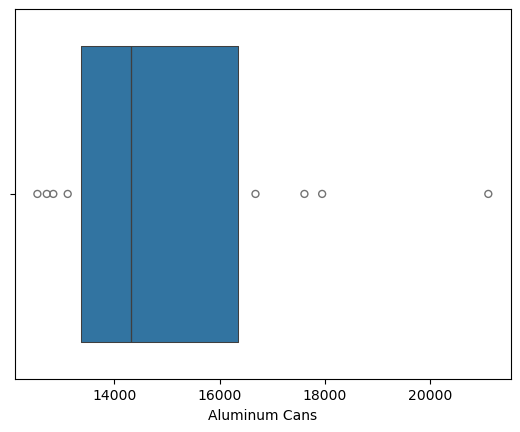

In [11]:
sns.boxenplot(data=data, x='Aluminum Cans')

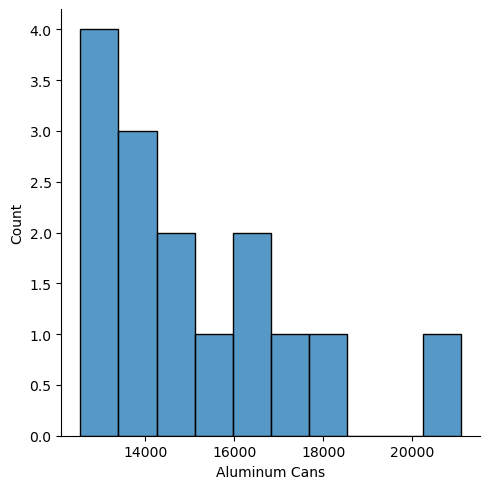

In [12]:
sns.displot(data=data, x='Aluminum Cans', bins = 10)

# Inter  Quartile Range (IQR) Method

In [13]:
# 1. Calculate Quartiles and IQR for 'Aluminum Cans'
Q1 = data['Aluminum Cans'].quantile(0.25)
Q3 = data['Aluminum Cans'].quantile(0.75)
IQR = Q3 - Q1

In [14]:
IQR

np.float64(2969.5)

In [15]:
# 2. Define upper and lower bounds
ll = lower_bound = Q1 - 1.5 * IQR
ul = upper_bound = Q3 + 1.5 * IQR

In [16]:
print('Lower Limit',lower_bound,'\nUpper Limit', upper_bound)

Lower Limit 8920.75 
Upper Limit 20798.75


In [17]:
# 3. Filter out the outliers
outliers_iqr = data[(data['Aluminum Cans'] < lower_bound) | (data['Aluminum Cans'] > upper_bound)]
clean_data_iqr = data[(data['Aluminum Cans'] >= lower_bound) & (data['Aluminum Cans'] <= upper_bound)]

print(f"Number of outliers detected via IQR: {len(outliers_iqr)}")

Number of outliers detected via IQR: 1


In [18]:
# Make sure each condition is fully enclosed in parentheses () 
# and the syntax for both sides is complete.
data[(data['Aluminum Cans'] <= lower_bound) | (data['Aluminum Cans'] >= upper_bound)]['Aluminum Cans']

9    21098
Name: Aluminum Cans, dtype: int64

# How to Handle Outliers

In [19]:
import numpy as np
np.where(data['Aluminum Cans'] <= lower_bound)

(array([], dtype=int64),)

In [20]:
np.where(data['Aluminum Cans'] >= upper_bound)

(array([9]),)

In [21]:
data['Aluminum Cans'][9]

np.int64(21098)

In [22]:
ll

np.float64(8920.75)

In [23]:
ul

np.float64(20798.75)

In [24]:
data['Aluminum Cans'].values

array([17944, 12540, 12718, 17608, 16010, 15441, 14951, 14005, 12842,
       21098, 13655, 13115, 13635, 16679, 14309])

In [25]:
arr = data['Aluminum Cans'].values

In [26]:
true_index = (ll < arr ) & (arr < ul )

In [27]:
true_index

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
       False,  True,  True,  True,  True,  True])

In [28]:
mid = np.median(data['Aluminum Cans'][true_index])

In [29]:
mid

np.float64(14157.0)

In [30]:
false_index = ~true_index

In [31]:
data['Aluminum Cans'].values[false_index] = mid

In [32]:
def highlight_cell(x):
    # Create a DataFrame of empty styles with the same shape as your data
    df_styler = pd.DataFrame('', index=x.index, columns=x.columns)
    # Set the background color for your specific row index and column name
    df_styler.at[9, 'Aluminum Cans'] = 'background-color: yellow; color: black; font-weight: bold'
    return df_styler

# Apply the style and display the DataFrame
data.style.apply(highlight_cell, axis=None)

,Year,Agricultural Organic Waste,Aluminum Cans,Anti-freeze,Appliances/White Goods,"Ash, Sand & Dust used",Asphalt/Concrete,Batteries,Cardboard,Glass,Paper,Plastics,Textiles,Wood,Rubber,Leather,Yard Trimmings,Food Waste,Electronics,Metals,Demolition Debris,Hazardous Waste,Other_Waste_Type_1,Other_Waste_Type_2,Other_Waste_Type_3,Other_Waste_Type_4,Other_Waste_Type_5,Other_Waste_Type_6,Other_Waste_Type_7,Other_Waste_Type_8,Other_Waste_Type_9,Other_Waste_Type_10,Other_Waste_Type_11,Other_Waste_Type_12,Other_Waste_Type_13,Other_Waste_Type_14,Other_Waste_Type_15,Other_Waste_Type_16,Other_Waste_Type_17,Other_Waste_Type_18,Other_Waste_Type_19,Other_Waste_Type_20,Other_Waste_Type_21,Other_Waste_Type_22,Other_Waste_Type_23,Other_Waste_Type_24,Other_Waste_Type_25,Other_Waste_Type_26,Other_Waste_Type_27,Other_Waste_Type_28,Other_Waste_Type_29,Other_Waste_Type_30,Other_Waste_Type_31,Other_Waste_Type_32,Other_Waste_Type_33,Other_Waste_Type_34,Other_Waste_Type_35,Other_Waste_Type_36,Other_Waste_Type_37,Other_Waste_Type_38,Other_Waste_Type_39,Other_Waste_Type_40,Other_Waste_Type_41,Other_Waste_Type_42,Other_Waste_Type_43,Other_Waste_Type_44,Other_Waste_Type_45,Other_Waste_Type_46,Other_Waste_Type_47,Other_Waste_Type_48,Other_Waste_Type_49,Other_Waste_Type_50,Other_Waste_Type_51,Other_Waste_Type_52,Other_Waste_Type_53,Other_Waste_Type_54,Other_Waste_Type_55,Other_Waste_Type_56,Other_Waste_Type_57,Other_Waste_Type_58
0,2000,0,17944,2475,35427,10000,893218,25795,133104,11267,3863,4000,62185,16736,2731,4191,119163,2675,4659,4233,1147,1959,4090,98354,4493,4193,68589,1139,6514,2950,3769,106179,75945,70056,5244,15881,109275,13373,83496,109031,50728,15486,16731,1365,6102,20188,4175,17114,5008,1015,4613,4583,3037,3858,135392,25183,6400,4555,23623,4580,16371,6312,12590,6789,6734,2376,120792,2898,19184,2035,28249,149097,1639,3797,1332,23490,966,10951,26002,24295
1,2001,0,12540,4157,39180,12333,1116871,10860,103707,27912,3978,7298,113704,10391,2773,1757,75939,1282,1291,7431,4282,2385,2056,52557,1300,5936,93484,190,5401,4131,574,82093,140852,95543,5856,24069,122369,22161,110692,138726,100517,18335,25368,499,6634,24683,2933,23323,5279,1824,4571,1823,4858,4982,137369,16238,3023,7220,15126,2075,24369,5948,27447,3346,4526,2832,115441,77,29096,477,21104,121315,827,1792,201,27589,4944,12079,23087,20682
2,2002,0,12718,4506,43833,290,1451959,15390,135305,21394,5056,2661,136779,23986,1570,1678,98925,709,3581,6010,3397,2919,3170,88360,4911,3062,132989,2300,4186,4780,3261,119678,82217,106556,6545,12849,61938,12082,139084,57357,116234,14491,27337,1680,6022,10504,3284,11353,3424,4469,2000,2081,1848,7042,69963,16090,4893,3776,15122,713,22910,3812,14324,5262,6244,2824,134555,2621,12192,1254,23429,127834,2730,2861,3507,22951,3432,12717,14873,26380
3,2003,0,17608,4722,53353,10576,1600288,21964,78693,13556,3275,6797,89099,22666,2690,3242,92941,4744,3457,2702,2511,4736,1682,132018,3987,4985,86212,980,5509,4115,1148,130738,58308,53343,3743,17390,85195,26281,142920,82479,89954,21130,12539,510,6768,11214,4298,20975,5456,3136,2756,3419,4719,4517,105123,21637,5617,5266,28030,1062,17943,3960,20787,3641,3401,1994,123698,4227,11248,922,16371,64153,3531,3476,4212,22312,688,19692,11481,18519
4,2004,0,16010,8050,56920,40409,2002171,21284,121932,13890,6514,4481,58571,15892,3840,4636,71834,4413,1636,5755,1794,1802,2255,52200,1527,5854,93525,2975,2654,2368,1715,89734,55949,63500,5618,21922,141680,25305,94425,111476,97280,17651,17056,4312,7248,11531,2811,21023,4081,2193,1668,1574,2814,3831,142705,22647,5093,2802,27302,1976,22199,5209,19111,4310,7285,2958,55415,600,21246,419,16359,126325,4451,3417,574,11990,4243,17311,20093,29694
5,2005,0,15441,8767,47302,14588,1783418,16265,143016,18838,2534,3495,88044,13561,1028,1059,68047,3748,3696,6718,659,4061,1154,118497,1218,2725,97202,1184,5037,3847,4777,122615,101990,103222,4641,12489,54000,19817,88756,94811,129459,11167,21516,1324,7349,10823,1250,10667,5824,223,1460,249,3374,6844,123477,19911,4468,3138,29181,1296,25728,4824,15342,3223,4539,2038,8

In [33]:
# checking for ouliers

def highlight_outliers(val):
    if val >= upper_bound or val <= lower_bound:
        return 'background-color: yellow; color: black; font-weight: bold;'
    return ''

# By adding [['Year', 'Aluminum Cans']], we filter out the other 50+ columns 
# so the styling renders perfectly on your screen!
data[['Year', 'Aluminum Cans']].style.map(highlight_outliers, subset=['Aluminum Cans'])

,Year,Aluminum Cans
0,2000,17944
1,2001,12540
2,2002,12718
3,2003,17608
4,2004,16010
5,2005,15441
6,2006,14951
7,2007,14005
8,2008,12842
9,2009,14157


In [34]:
data

,Year,Agricultural Organic Waste,Aluminum Cans,Anti-freeze,Appliances/White Goods,"Ash, Sand & Dust used",Asphalt/Concrete,Batteries,Cardboard,Glass,...,Other_Waste_Type_49,Other_Waste_Type_50,Other_Waste_Type_51,Other_Waste_Type_52,Other_Waste_Type_53,Other_Waste_Type_54,Other_Waste_Type_55,Other_Waste_Type_56,Other_Waste_Type_57,Other_Waste_Type_58
0,2000,0,17944,2475,35427,10000,893218,25795,133104,11267,...,28249,149097,1639,3797,1332,23490,966,10951,26002,24295
1,2001,0,12540,4157,39180,12333,1116871,10860,103707,27912,...,21104,121315,827,1792,201,27589,4944,12079,23087,20682
2,2002,0,12718,4506,43833,290,1451959,15390,135305,21394,...,23429,127834,2730,2861,3507,22951,3432,12717,14873,26380
3,2003,0,17608,4722,53353,10576,1600288,21964,78693,13556,...,16371,64153,3531,3476,4212,22312,688,19692,11481,18519
4,2004,0,16010,8050,56920,40409,2002171,21284,121932,13890,...,16359,126325,4451,3417,574,11990,4243,17311,20093,29694
5,2005,0,15441,8767,47302,14588,1783418,16265,143016,18838,...,17863,62999,2935,1645,536,15299,3701,28449,29835,13300
6,2006,0,14951,7507,49796,4008,2295278,26850,75658,24502,...,13228,105318,3876,1205,1625,22997,341,10768,24422,16722
7,2007,0,14005,7055,44667,2521,2089972,14426,134478,20627,...,24382,50814,126,3030,2122,29956,1724,15490,26438,17218
8,2008,31800,12842,6586,43401,0,1510051,24423,68431,18792,...,28755,126077,3177,2872,385,23472,4422,25534,17643,13054
9,2009,45431,14157,5194,39777,344,2186429,21363,52747,20555,...,12891,140474,3056,3072,3281,14380,1792,16645,29846,23575


In [35]:
data.columns

Index(['Year', 'Agricultural Organic Waste', 'Aluminum Cans', 'Anti-freeze',
       'Appliances/White Goods', 'Ash, Sand & Dust used', 'Asphalt/Concrete',
       'Batteries', 'Cardboard', 'Glass', 'Paper', 'Plastics', 'Textiles',
       'Wood', 'Rubber', 'Leather', 'Yard Trimmings', 'Food Waste',
       'Electronics', 'Metals', 'Demolition Debris', 'Hazardous Waste',
       'Other_Waste_Type_1', 'Other_Waste_Type_2', 'Other_Waste_Type_3',
       'Other_Waste_Type_4', 'Other_Waste_Type_5', 'Other_Waste_Type_6',
       'Other_Waste_Type_7', 'Other_Waste_Type_8', 'Other_Waste_Type_9',
       'Other_Waste_Type_10', 'Other_Waste_Type_11', 'Other_Waste_Type_12',
       'Other_Waste_Type_13', 'Other_Waste_Type_14', 'Other_Waste_Type_15',
       'Other_Waste_Type_16', 'Other_Waste_Type_17', 'Other_Waste_Type_18',
       'Other_Waste_Type_19', 'Other_Waste_Type_20', 'Other_Waste_Type_21',
       'Other_Waste_Type_22', 'Other_Waste_Type_23', 'Other_Waste_Type_24',
       'Other_Waste_Type_25', '

# Program 2

In [36]:
# outliers dection and handling in 'Ash, Sand & Dust used' in 'Asphalt/Concrete' productionabs
import numpy as np 
import pandas as pd 
import seaborn as sns
d2 = pd.read_csv(r"C:\Users\HP\A  Self Pace ML\18. Outliers\solid_waste_generation_recycling.csv")
# no of rows and columns
d2.shape



(15, 80)

In [37]:
# rename the column: 'Ash, Sand & Dust used' 
# Production as target column
# pass distionary with old name and new name 
d2.rename(columns={'Ash, Sand & Dust used': 'Target'}, inplace=True)



In [38]:
# let us find outliers , sort on target column
df1 = d2.sort_values('Target')

df1['Target'].head()

df1['Target'].tail()



3     10576
1     12333
5     14588
10    20364
4     40409
Name: Target, dtype: int64

In [39]:
df1[df1['Target'] == 40409].index
df1.index[-1]

np.int64(4)

In [40]:
# display the all rows of target column (this is the 5th column)
# 0s cannot be outliers but the last row is 40409 this is outliers
df.iloc[:,5]



1     12333
2       290
8         0
11        0
12        0
10    20364
7      2521
14        0
6      4008
5     14588
4     40409
13        0
3     10576
0     10000
9       344
Name: Ash, Sand & Dust used, dtype: int64

<Axes: xlabel='Target'>

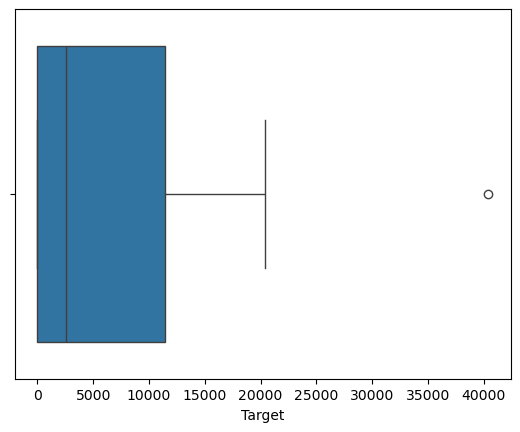

In [41]:
# let us find outliers bt drawing graphs / plots
# from the below plot, the outlires is after 40000 
sns.boxplot(data=d2 , x = 'Target')


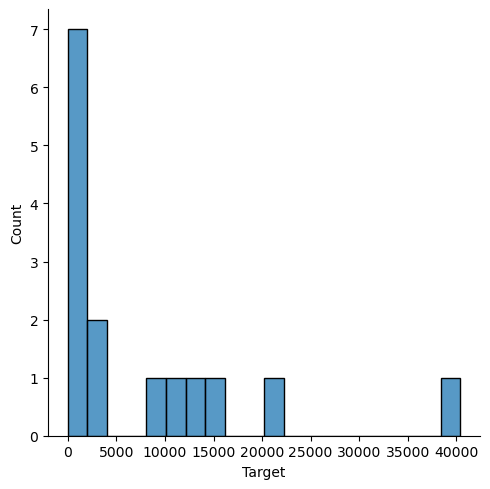

In [42]:
sns.displot(data= d2,x='Target', bins = 20)


In [43]:

# calculate IQR
q3 = d2['Target'].quantile(.75) 
q1 = d2['Target'].quantile(.25)



In [44]:
print('q1',q1)
print('q3',q3)

# Find IQR 
iqr = q3 - q1
iqr



q1 0.0
q3 11454.5


np.float64(11454.5)

In [45]:
# calculate upper and lower limit
ul = q3 +(1.5*iqr)
ll = q1 -(1.5*iqr)
print(ul,ll)



28636.25 -17181.75


In [46]:
def highlight_target_outliers(val):
    # Use limits (28636.25 and 17181.75)
    if val >= ul or val <= ll:
        return 'background-color: yellow; color: black; font-weight: bold;'
    return ''

In [47]:

df1[['Year', 'Target']].style.map(highlight_target_outliers, subset=['Target'])


,Year,Target
8,2008,0
11,2011,0
12,2012,0
13,2013,0
14,2014,0
2,2002,290
9,2009,344
7,2007,2521
6,2006,4008
0,2000,10000


In [48]:
upper = np.where(d2['Target']>=ul)
lower = np.where(d2['Target']<=ll)

In [49]:
# delete the rows above upper and below lower values 
d2.drop(upper[0], inplace=True) 
d2.drop(lower[0], inplace=True)

In [50]:

# if arr values are in between ll and ul , represent that 
# calue as True else as False 
# False values are outliers - we can find it at 5th position 
arr = df1['Target'].values
true_index = (ll < arr) & (arr < ul)
true_index


array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True, False])

In [51]:

# let us substutute mean value inthe place of outliers
# so calculate mean of all values other than the outliers. 
# 1. Calculate the mean ('mid') using ONLY the valid non-outlier rows from df1
mid = df1.loc[true_index, 'Target'].mean()
mid


np.float64(5358.857142857143)

In [52]:
# 2. Create the false_index mask to isolate ONLY the outlier rows
false_index = ~true_index

In [55]:

# 3. Replace ONLY the outliers in df1 with that clean mean value
df1['Target'].values[false_index] = mid


In [56]:

# 4. View your updated dataframe
df1['Target']


8         0
11        0
12        0
13        0
14        0
2       290
9       344
7      2521
6      4008
0     10000
3     10576
1     12333
5     14588
10    20364
4      5358
Name: Target, dtype: int64

In [57]:

def highlight_target_outliers(val):
    # Use limits (28636.25 and 17181.75)
    if val >= ul or val <= ll:
        return 'background-color: yellow; color: black; font-weight: bold;'
    return ''

df1[['Year', 'Target']].style.map(highlight_target_outliers, subset=['Target'])


,Year,Target
8,2008,0
11,2011,0
12,2012,0
13,2013,0
14,2014,0
2,2002,290
9,2009,344
7,2007,2521
6,2006,4008
0,2000,10000


In [58]:

def highlight_cell(x):
    # Create a DataFrame of empty styles with the same shape as your data
    df_styler = pd.DataFrame('', index=x.index, columns=x.columns)
    # Set the background color for your specific row index and column name
    df_styler.at[5, 'Target'] = 'background-color: yellow; color: black; font-weight: bold'
    return df_styler

df1.style.apply(highlight_cell, axis=None)


,Year,Agricultural Organic Waste,Aluminum Cans,Anti-freeze,Appliances/White Goods,Target,Asphalt/Concrete,Batteries,Cardboard,Glass,Paper,Plastics,Textiles,Wood,Rubber,Leather,Yard Trimmings,Food Waste,Electronics,Metals,Demolition Debris,Hazardous Waste,Other_Waste_Type_1,Other_Waste_Type_2,Other_Waste_Type_3,Other_Waste_Type_4,Other_Waste_Type_5,Other_Waste_Type_6,Other_Waste_Type_7,Other_Waste_Type_8,Other_Waste_Type_9,Other_Waste_Type_10,Other_Waste_Type_11,Other_Waste_Type_12,Other_Waste_Type_13,Other_Waste_Type_14,Other_Waste_Type_15,Other_Waste_Type_16,Other_Waste_Type_17,Other_Waste_Type_18,Other_Waste_Type_19,Other_Waste_Type_20,Other_Waste_Type_21,Other_Waste_Type_22,Other_Waste_Type_23,Other_Waste_Type_24,Other_Waste_Type_25,Other_Waste_Type_26,Other_Waste_Type_27,Other_Waste_Type_28,Other_Waste_Type_29,Other_Waste_Type_30,Other_Waste_Type_31,Other_Waste_Type_32,Other_Waste_Type_33,Other_Waste_Type_34,Other_Waste_Type_35,Other_Waste_Type_36,Other_Waste_Type_37,Other_Waste_Type_38,Other_Waste_Type_39,Other_Waste_Type_40,Other_Waste_Type_41,Other_Waste_Type_42,Other_Waste_Type_43,Other_Waste_Type_44,Other_Waste_Type_45,Other_Waste_Type_46,Other_Waste_Type_47,Other_Waste_Type_48,Other_Waste_Type_49,Other_Waste_Type_50,Other_Waste_Type_51,Other_Waste_Type_52,Other_Waste_Type_53,Other_Waste_Type_54,Other_Waste_Type_55,Other_Waste_Type_56,Other_Waste_Type_57,Other_Waste_Type_58
8,2008,31800,12842,6586,43401,0,1510051,24423,68431,18792,4085,7051,98984,18392,870,3157,65707,1998,698,6889,1986,623,1696,127505,3104,7048,83828,127,3284,971,2491,67019,124740,66964,5459,19540,147856,18808,97295,121180,122936,21174,23964,3141,3581,23428,3376,13719,7304,3925,4809,2165,3981,7137,119836,13266,4761,3025,18172,3596,12472,5063,24043,6708,4173,1118,137388,2343,14018,3068,28755,126077,3177,2872,385,23472,4422,25534,17643,13054
11,2011,76645,13115,4872,44174,0,2211189,18322,115725,18433,3521,3516,112592,29488,1484,1597,73776,1495,4737,2697,2911,4976,4682,100108,954,7254,146752,569,5306,2774,3051,136672,66896,135067,7146,29223,132986,15745,67955,71352,119896,15334,29065,2923,3394,13627,1396,10539,2509,1633,4146,4363,4530,4628,95002,27055,5378,4625,16882,66,11761,4897,23917,7249,6213,235,108596,4711,18389,2243,25770,125993,3449,4021,417,29097,3212,21485,21271,12143
12,2012,102732,13635,6797,54578,0,1887580,11685,134654,20233,5961,2837,117563,12454,863,3060,80080,3304,854,4430,1734,2049,1648,144179,4565,7142,50301,1895,3037,1982,4,123847,96175,117215,4135,15878,139643,21338,87841,105069,85270,18924,27924,2214,3884,22972,3637,14964,5371,2152,4780,1984,2150,4680,56254,20161,6643,5787,11906,232,20167,6235,28935,6915,4119,1969,80523,3597,27586,2645,26478,125916,4146,4662,3600,20395,989,15797,27216,19503
13,2013,97270,16679,4804,31192,0,2196139,10769,85773,21016,5113,3378,52695,21837,2790,2693,116842,3763,3474,6082,1843,3723,1445,140272,3446,5620,95236,2733,4341,853,4869,132750,57805,119042,4257,26347,70764,10412,120640,64397,109163,14330,23807,4186,4458,11852,3330,14835,3297,510,716,1077,4859,7392,67144,21314,6144,2864,13086,2156,20554,5370,24309,4073,2820,4429,138861,3762,25374,1857,12674,123319,3533,2708,954,26241,2262,29719,22600,25149
14,2014,66660,14309,4955,37882,0,2389936,12433,117435,12612,6343,3576,98190,24039,563,4891,111373,1853,1707,3108,488,4548,4199,88467,1045,2516,116235,3863,4955,4146,876,129634,55237,63284,6952,10851,136027,17543,115510,91555,132637,16801,19580,713,5572,14910,2703,16042,7472,384,4544,235,1329,2637,74214,22891,6932,7121,23503,1169,27260,3660,23234,4328,3842,1908,136740,4670,15788,4612,16898,67368,3367,3502,4971,15588,2482,22342,20998,28922
2,2002,0,12718,4506,43833,290,1451959,15390,135305,21394,5056,2661,136779,23986,1570,1678,98925,709,3581,6010,3397,2919,3170,88360,4911,3062,132989,2300,4186,4780,3261,119678,82217,106556,6545,12849,61938,12082,139084,57357,116234,14491,27337,1680,6022,10504,3284,11353,3424,4469,2000,2081,1848,7042,69963,16090,4893,3776,15122,713,22910,3812,14324,5262,6244,2824,134555,2621,12192

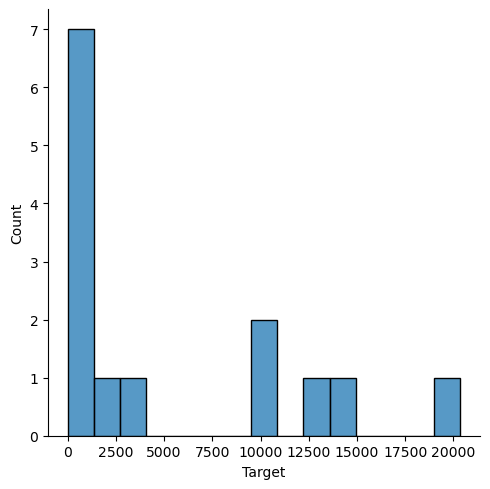

In [59]:

sns.displot(data=d2, x= 'Target', bins = 15)


In [60]:

df1['Target']

8         0
11        0
12        0
13        0
14        0
2       290
9       344
7      2521
6      4008
0     10000
3     10576
1     12333
5     14588
10    20364
4      5358
Name: Target, dtype: int64